In [188]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score, cross_val_predict, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, f1_score

## Exploratory Data Analysis

In [153]:
df = pd.read_csv('dataset_8k.csv')

df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [154]:
df.rename(columns={
    'N': 'nitrogen',
    'P': 'phosphorus',
    'K': 'potassium',
    }, inplace=True)

df.head()

,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


- Nitrogen: mg/kg
- Potassium: mg/kg
- Phosporus: mg/kg
- Temperature: Celcius
- Humidity
- pH
- Rainfall: per month in mm

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nitrogen     8800 non-null   int64  
 1   phosphorus   8800 non-null   int64  
 2   potassium    8800 non-null   int64  
 3   temperature  8800 non-null   float64
 4   humidity     8800 non-null   float64
 5   ph           8800 non-null   float64
 6   rainfall     8800 non-null   float64
 7   label        8800 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 550.1+ KB


In [156]:
df.describe(include="all")

,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label
count,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800.000000,8800
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rice
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400
mean,55.080909,51.444091,40.482727,26.774572,71.443720,6.609499,100.669506,NaN
std,37.059675,27.973451,38.555468,5.322922,22.761454,0.877838,56.017885,NaN
min,0.000000,4.000000,5.000000,8.825675,14.258040,3.504752,20.211267,NaN
25%,25.000000,30.000000,20.000000,23.826868,58.192235,6.081469,60.745835,NaN
50%,42.000000,51.000000,29.000000,26.924435,79.960550,6.566980,90.402966,NaN
75%,89.000000,66.000000,46.000000,29.774256,89.417267,7.086870,122.704272,NaN


In [157]:
missing_rate = df.isna().mean().sort_values(ascending=False).round(4)

print(missing_rate)

nitrogen       0.0
phosphorus     0.0
potassium      0.0
temperature    0.0
humidity       0.0
ph             0.0
rainfall       0.0
label          0.0
dtype: float64


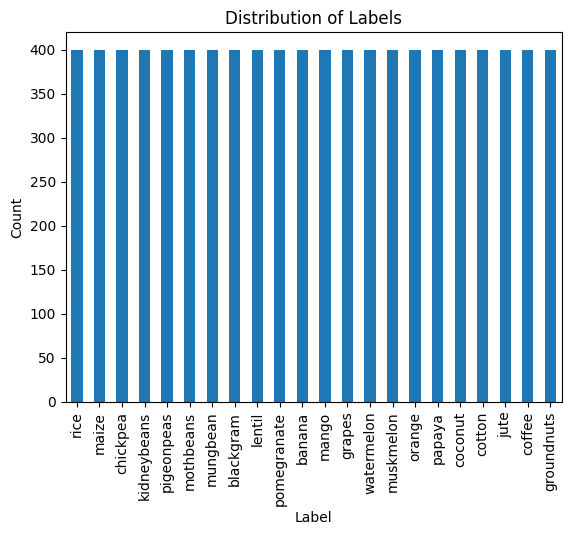

In [158]:
df["label"].value_counts().plot(kind="bar")
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Labels")
plt.show()

In [159]:
dup_rate = df.duplicated().mean()
df.drop_duplicates()

print(dup_rate)

0.0


In [160]:
total_labels = df["label"].nunique()
print(f"Total unique labels: {total_labels}")

Total unique labels: 22


## Feature Engineering

In [161]:
# df['npk_total'] = df['nitrogen'] + df['phosphorus'] + df['potassium']
# df["npk_product"] = df["nitrogen"] * df["phosphorus"] * df["potassium"]

# df['n_p_ratio'] = df['nitrogen'] / (df['phosphorus'] + 1e-6)
# df['n_k_ratio'] = df['nitrogen'] / (df['potassium'] + 1e-6)
# df['p_k_ratio'] = df['phosphorus'] / (df['potassium'] + 1e-6)

# df["temp_humidity"] = df["temperature"] * df["humidity"]
# df["humidity_rain_ratio"] = df["humidity"] / (df["rainfall"] + 1e-6)

# df["ph_deviation"] = abs(df["ph"] - 7)

# df['ph_acidic']   = (df['ph'] < 6.0).astype(int)
# df['ph_neutral']  = ((df['ph'] >= 6.0) & (df['ph'] <= 7.5)).astype(int)
# df['ph_alkaline'] = (df['ph'] > 7.5).astype(int)

df.head()

,nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


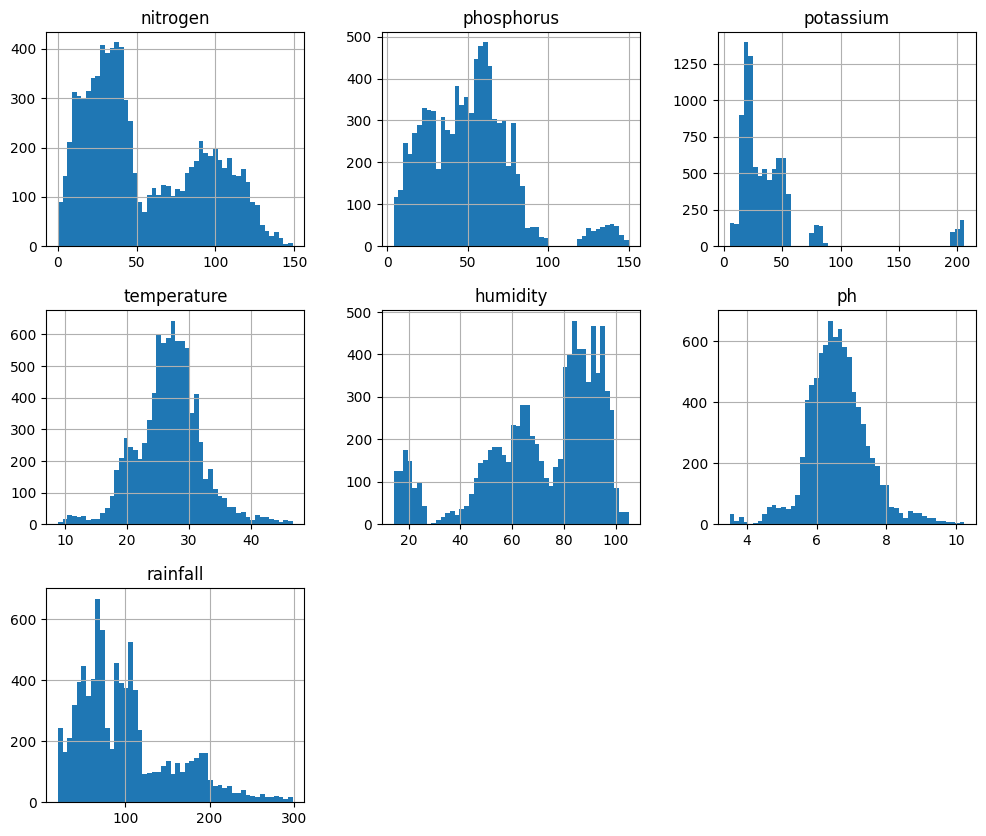

In [162]:
df.hist(bins=50, figsize=(12,10))
plt.show()

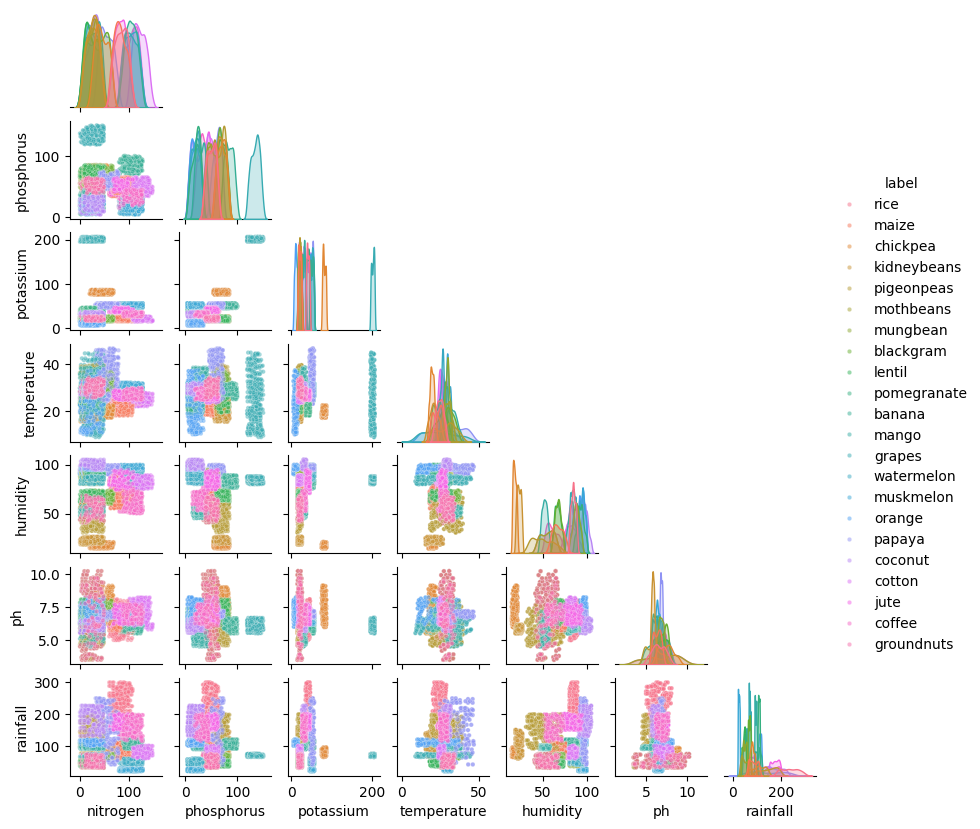

In [163]:
sns.pairplot(
    df,
    hue="label",
    corner=True,
    height=1.2,
    plot_kws={'s': 10, 'alpha': 0.5},   # smaller points
)

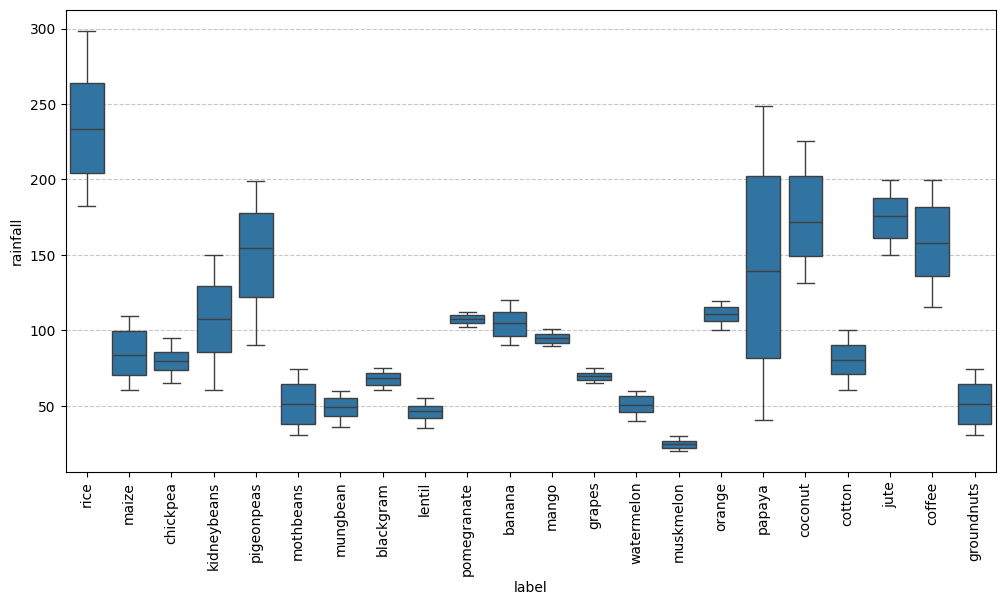

In [164]:
plt.figure(figsize=(12,6))
sns.boxplot(x="label", y="rainfall", data=df)
plt.xticks(rotation=90)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

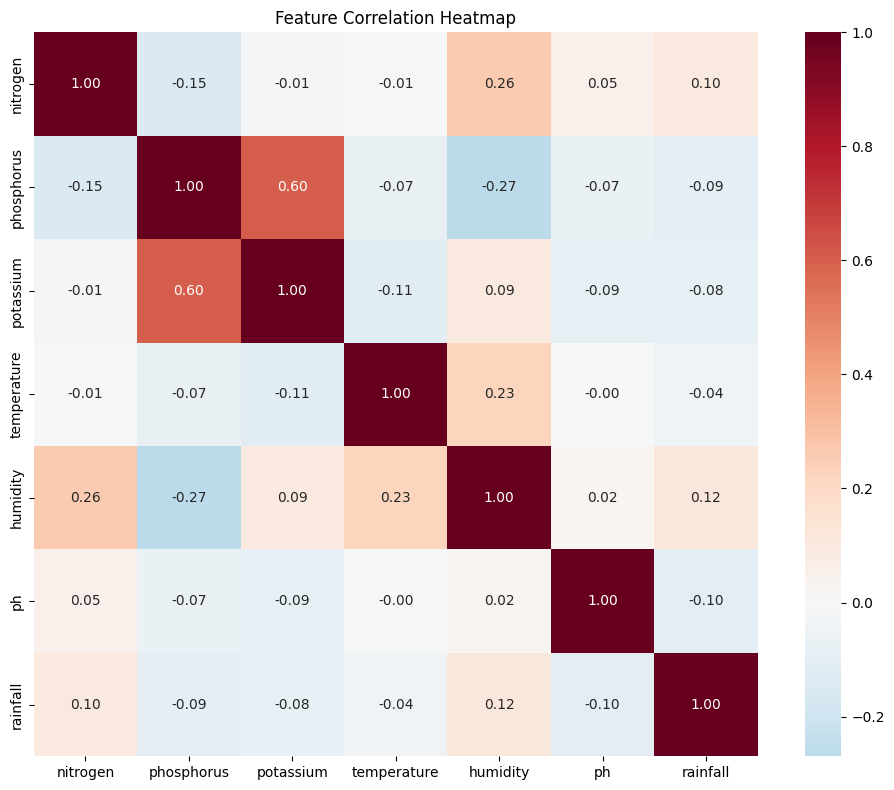

In [165]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Preprocessing

In [166]:
le = LabelEncoder()
df["le_label"] = le.fit_transform(df["label"])

In [167]:
X = df.drop(["label", "le_label"], axis=1)
y = df["le_label"]

In [168]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

In [169]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Baseline Model

In [170]:
def show_learning_curve(model, name, X, y, cv):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring='balanced_accuracy',
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # training curve
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label=f'Training score: {train_mean[-1]:.4f}')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='blue')

    # validation curve
    plt.plot(train_sizes, test_mean, 'o-', color='green', label=f'Validation score: {test_mean[-1]:.4f}')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color='green')

    plt.title(f'Learning Curve ({name})')
    plt.xlabel('Training Samples')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    plt.show()

In [171]:
def show_confusion_matrix(y_true, y_pred, display_labels):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(10, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=True)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

F1 Macro: 0.9282317136699495


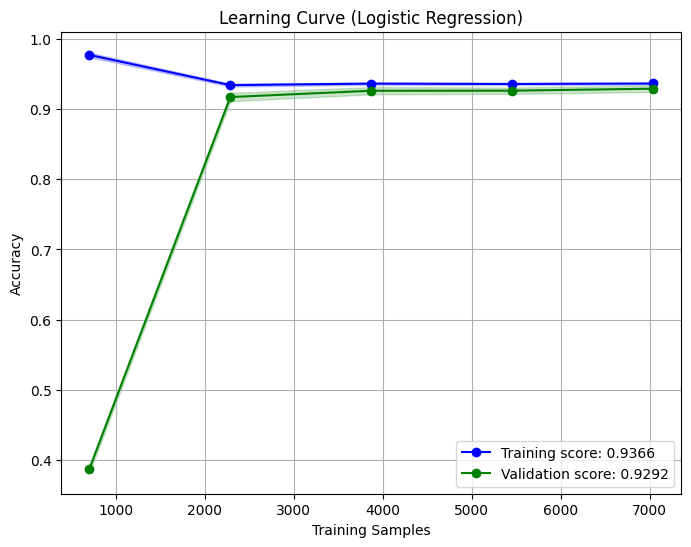

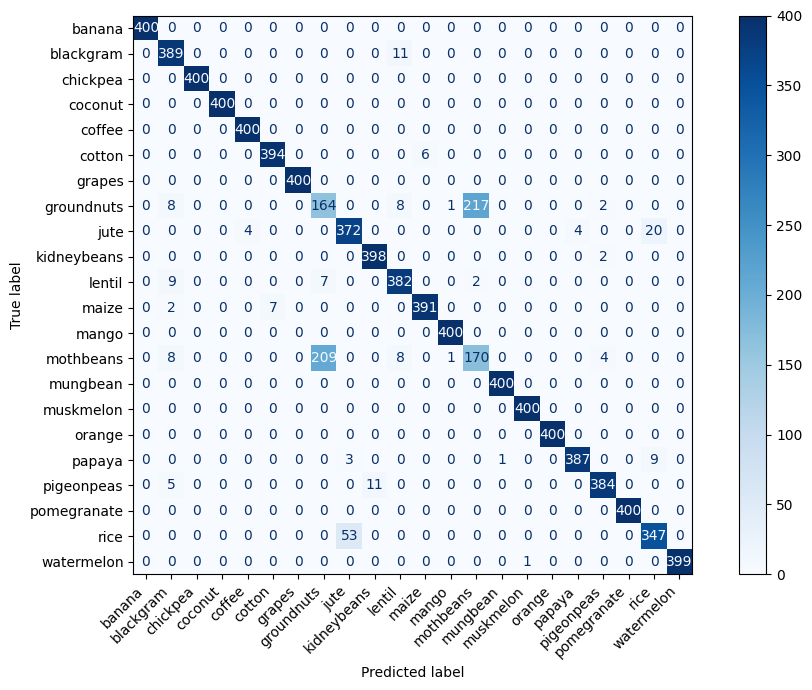

In [172]:
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

logreg_f1m = cross_val_score(logreg, X, y, cv=cv, scoring='f1_macro').mean()
print("F1 Macro:", logreg_f1m)
show_learning_curve(logreg, "Logistic Regression", X, y, cv)

logreg_pred = cross_val_predict(logreg, X, y, cv=cv)
show_confusion_matrix(y, logreg_pred, display_labels=le.classes_)

F1 Macro: 0.9389270611552936


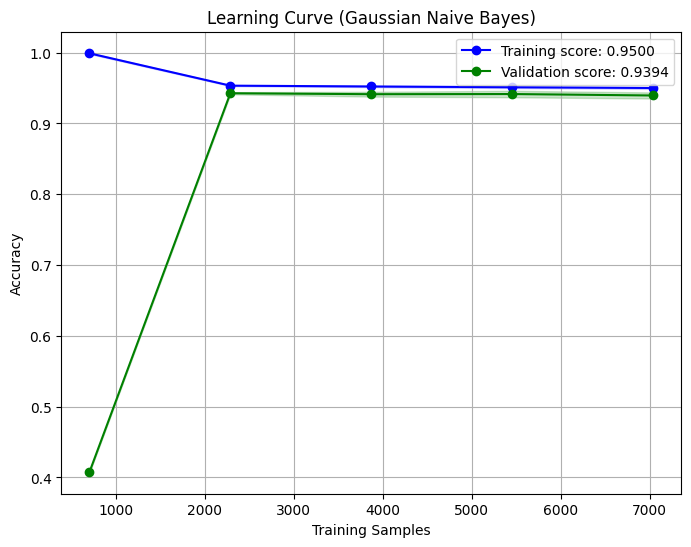

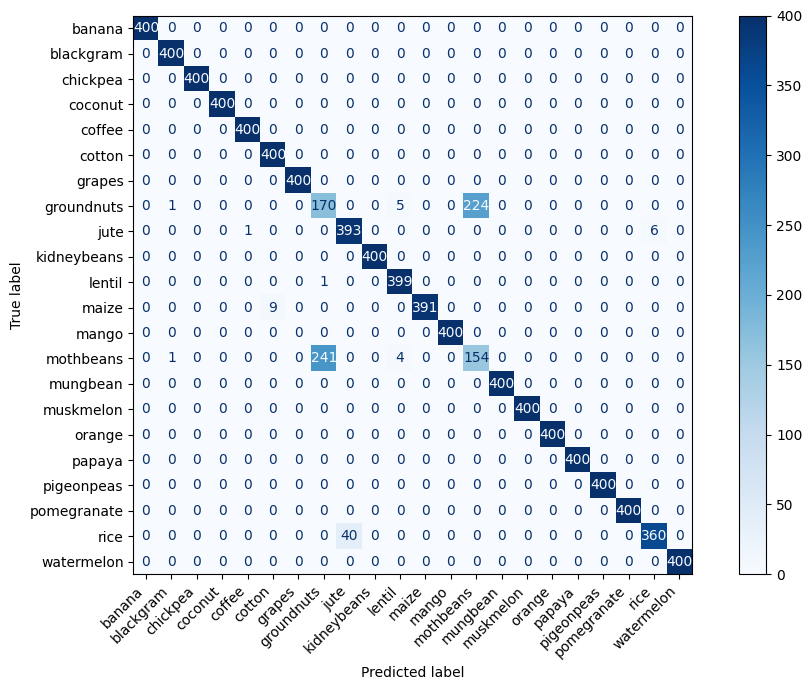

In [179]:
gnb = GaussianNB()

gnb_f1m = cross_val_score(gnb, X, y, cv=cv, scoring='f1_macro').mean()
print("F1 Macro:", gnb_f1m)
show_learning_curve(gnb, "Gaussian Naive Bayes", X, y, cv)

gnb_pred = cross_val_predict(gnb, X, y, cv=cv)
show_confusion_matrix(y, gnb_pred, display_labels=le.classes_)

F1 Macro: 0.9118237060274433


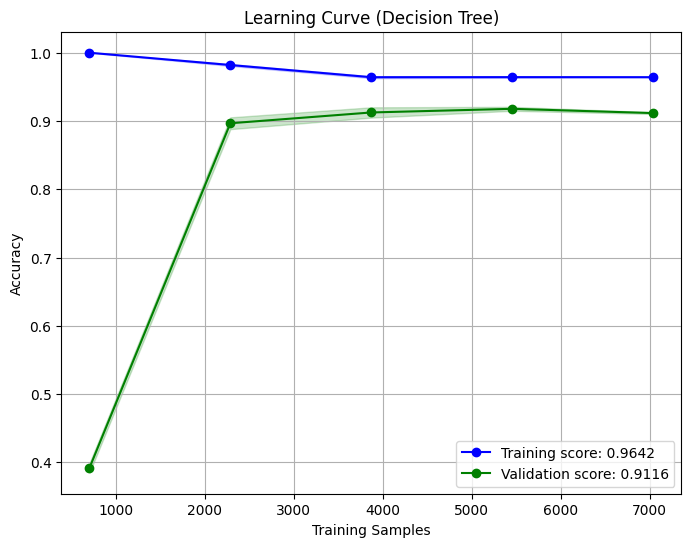

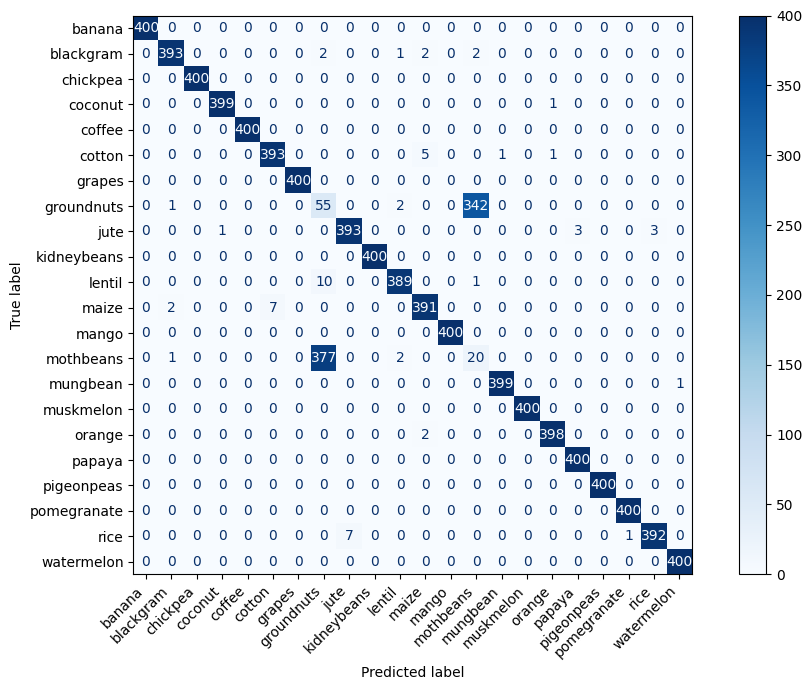

In [173]:
dt = DecisionTreeClassifier(random_state=42)

dt_f1m = cross_val_score(dt, X, y, cv=cv, scoring='f1_macro').mean()
print("F1 Macro:", dt_f1m)
show_learning_curve(dt, "Decision Tree", X, y, cv)

dt_pred = cross_val_predict(dt, X, y, cv=cv)
show_confusion_matrix(y, dt_pred, display_labels=le.classes_)

In [174]:
def feature_importance(model, X, y):
    model.fit(X, y)
    # get feature importances
    importances = model.feature_importances_
    feature_names = X.columns

    # sort importances descending
    indices = np.argsort(importances)[::-1]
    sorted_importances = importances[indices]
    sorted_features = [feature_names[i] for i in indices]

    plt.figure(figsize=(10, 6))
    plt.barh(sorted_features, sorted_importances, color="green")
    plt.xlabel("Feature Importance")
    plt.title("Feature Importance from Classifier")
    plt.gca().invert_yaxis()  # highest importance on top
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

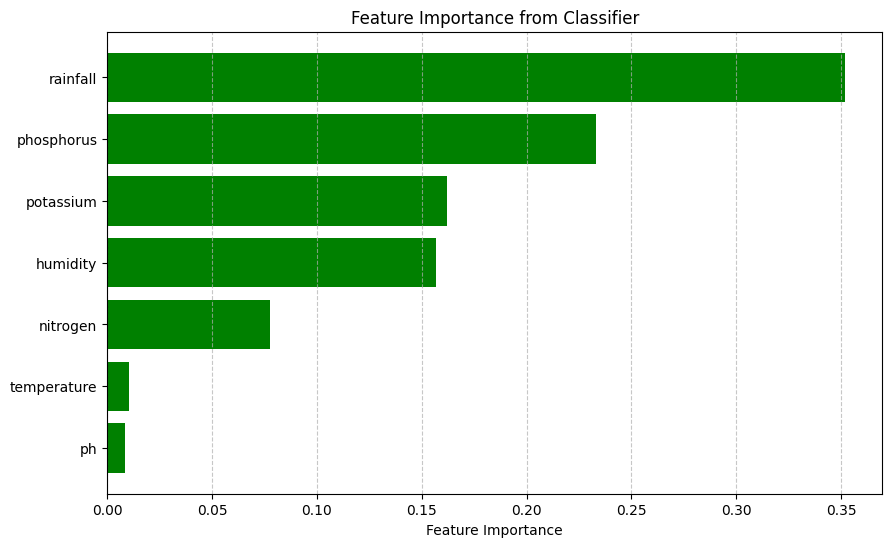

In [175]:
feature_importance(dt, X, y)

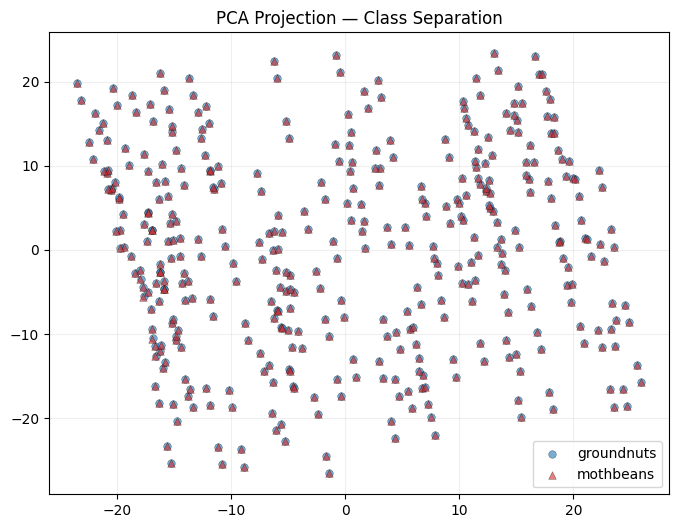

In [176]:
mask = df['label'].isin(['groundnuts', 'mothbeans'])
df_pair = df[mask].copy()
class0 = df_pair[df_pair['label'] == 'groundnuts']
class1 = df_pair[df_pair['label'] == 'mothbeans']

features = ['nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'ph', 'rainfall']

X_pair = df_pair[features].values
y_pair = df_pair['label'].values

X_pca = PCA(n_components=2).fit_transform(X_pair)

# boolean masks (cleaner than string indexing repeatedly)
mask_g = (y_pair == 'groundnuts')
mask_m = (y_pair == 'mothbeans')

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[mask_g, 0], X_pca[mask_g, 1],
    label='groundnuts',
    c='#1f77b4',  # strong blue
    marker='o',
    s=30,
    alpha=0.6,
    edgecolors='black',
    linewidths=0.3
)

plt.scatter(
    X_pca[mask_m, 0], X_pca[mask_m, 1],
    label='mothbeans',
    c='#d62728',  # strong red
    marker='^',
    s=30,
    alpha=0.6,
    edgecolors='black',
    linewidths=0.3
)

plt.title("PCA Projection — Class Separation")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## Main Model

In [181]:
logreg_clf = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

logreg_param_grid = {
    'poly__degree': [1, 2],
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['saga']
}

grid_search = GridSearchCV(
    estimator=logreg_clf,
    param_grid=logreg_param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV F1 Macro:", grid_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best Hyperparameters: {'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'saga', 'poly__degree': 1}
Best CV F1 Macro: 0.937910542605693


c:\Users\Nizwa\miniconda3\envs\ai\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


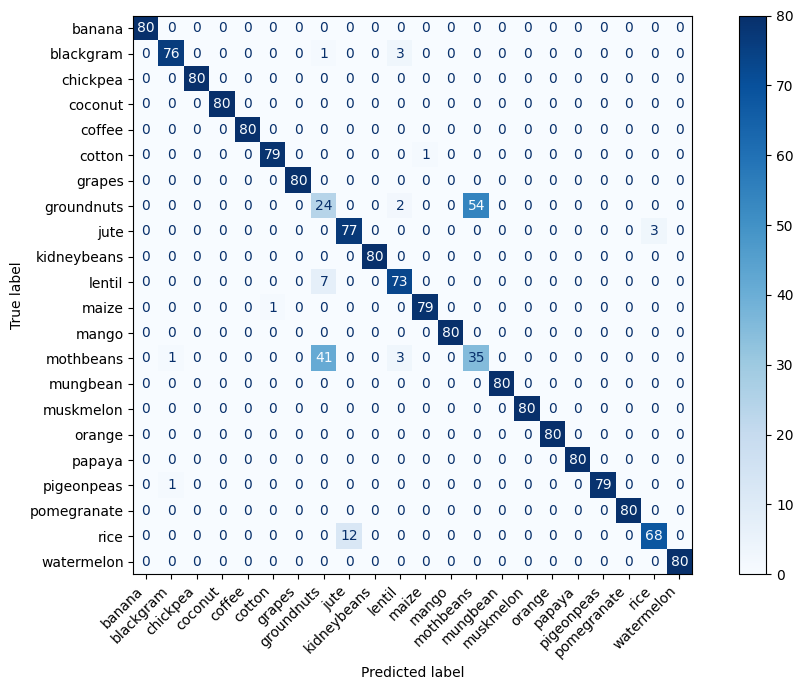

In [184]:
best_logreg = grid_search.best_estimator_

best_logreg_pred = best_logreg.predict(X_test)

show_confusion_matrix(y_test, best_logreg_pred, display_labels=le.classes_)

In [185]:
rf_clf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['log2', 'sqrt']
}

grid_search = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV F1 Macro:", grid_search.best_score_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Hyperparameters: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best CV F1 Macro: 0.9315978153885173


In [198]:
# clf1 = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model',  LogisticRegression(max_iter=1000))
# ])
# clf2 = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model',  KNeighborsClassifier())
# ])
clf3 = RandomForestClassifier(random_state=42)
clf4 = GaussianNB()
# clf5 = Pipeline([
#     ('scaler', StandardScaler()),
#     ('model',  SVC(kernel='rbf', probability=True, random_state=42))
# ])
# clf6 = DecisionTreeClassifier(random_state=42)

stack_clf = StackingClassifier(
    estimators=[
        # ('logreg', clf1),
        # ('knn',    clf2),
        ('dtree',  clf3),
        ('gnb',    clf4),
        # ('svc',    clf5),
        # ('dtree2', clf6)
    ],
    final_estimator=LogisticRegression(),
)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stack_f1 = cross_val_score(stack_clf, X, y, cv=kf, scoring='f1_macro').mean()
print("F1 Macro:", stack_f1)

F1 Macro: 0.9882933554610196


In [ ]:
# best_dt = grid_search.best_estimator_

# y_pred = best_dt.predict(X_test)

# balanced_acc = balanced_accuracy_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred, average='weighted')

# print("Balanced Accuracy:", balanced_acc)
# print("Weighted F1 Score:", f1)

In [178]:
report = classification_report(le.inverse_transform(y_test), le.inverse_transform(y_pred), output_dict=True)

df_report = pd.DataFrame(report).transpose()
df_report.head(total_labels + 4)

NameError: name 'y_pred' is not defined

In [ ]:
print("baseline finished")

baseline finished
